# Multiclass_Classification

In [2]:
import os
import sys
print(sys.executable)

/projappl/project_465002387/DEEP_Inspection_Material_Science/jupyter-env/bin/python3


In [6]:
import sys
import subprocess

print("Python executable:")
print(sys.executable)

print("\nTorch package:")
subprocess.run([sys.executable, "-m", "pip", "show", "torch"])

Python executable:
/projappl/project_465002387/DEEP_Inspection_Material_Science/jupyter-env/bin/python3

Torch package:
Name: torch
Version: 2.7.1+rocm6.2.4
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /opt/miniconda3/envs/pytorch/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, pytorch-triton-rocm, setuptools, sympy, typing-extensions
Required-by: accelerate, bitsandbytes, causal_conv1d, compressed-tensors, deepspeed, flash_attn, grouped_gemm, lighteval, lightning, lion-pytorch, mamba_ssm, nvidia-modelopt, peft, pytorch-lightning, runai-model-streamer, sentence-transformers, tensorizer, torchaudio, torchdata, torchmetrics, torchprofile, torchtext, torchvision, xformers, xgrammar


CompletedProcess(args=['/projappl/project_465002387/DEEP_Inspection_Material_Science/jupyter-env/bin/python3', '-m', 'pip', 'show', 'torch'], returncode=0)

In [4]:
import torch
print("Torch version:", torch.__version__)

ImportError: libroctx64.so: cannot open shared object file: No such file or directory

In [1]:
!pip install --upgrade pip
!pip install -q "tensorflow>=2.15.0" pandas matplotlib scikit-learn seaborn

In [ ]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.layers import Flatten, Dropout, Dense, Conv2D, MaxPool2D
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Dataset Setup
# Using Severstal Defect Dataset

This notebook uses the `Severstal: Steel Defect Detection` dataset, modified and containing 200 images each of 4 defect types:
- **Scratches**: Surface scratches and abrasions
- **Inclusions**: Foreign particles embedded in steel
- **Patches**: Localized surface irregularities  
- **Rolls Marks**: Marks from the rolling process

Directory structure:
```
single_class_sampled/
├── Scratches/      
├── Inclusions/     
├── Patches/         
└── Rolls Marks/    
```

In [4]:
# Define path to Severstal Steel Defect dataset
dataset_path = "C:\\Users\\marsa964\\MS-Workshop\\single_class_sampled"

# Verify dataset exists
if not os.path.exists(dataset_path):
    print(f"Error: {dataset_path} folder not found!")
else:
    print(f"Dataset path: {os.path.abspath(dataset_path)}")

Dataset path: C:\Users\marsa964\MS-Workshop\single_class_sampled


In [5]:
# Get sorted class names
class_names = sorted(os.listdir(dataset_path))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Count images per class
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{class_name}: {num_images} images")

Classes found: ['Inclusions', 'Patches', 'Rolls Marks', 'Scratches']
Number of classes: 4
Inclusions: 195 images
Patches: 500 images
Rolls Marks: 500 images
Scratches: 500 images


In [6]:
# Load full dataset
BATCH_SIZE = 32
IMAGE_SIZE = 255

full_dataset = keras.preprocessing.image_dataset_from_directory(
    directory=dataset_path,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    class_names=class_names,
    shuffle=True,
    seed=100
)

# Convert dataset to arrays
images = []
labels = []

for img_batch, label_batch in full_dataset:
    images.extend(img_batch.numpy())
    labels.extend(label_batch.numpy())

images = np.array(images)
labels = np.array(labels)

print(f"Total images: {len(images)}")
print(f"Total labels: {len(labels)}")

# First split: 70% train, 30% holdout (val+test)
X_train, X_holdout, y_train, y_holdout = train_test_split(
    images, labels, 
    test_size=0.3, 
    random_state=0
)

# Second split:  15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout,
    test_size=0.5,
    random_state=0
)

print(f"Training samples: {len(X_train)} ({len(X_train)/len(images)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(images)*100:.1f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(images)*100:.1f}%)")

# Convert back to tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

Found 1695 files belonging to 4 classes.
Total images: 1695
Total labels: 1695
Training samples: 1186 (70.0%)
Validation samples: 254 (15.0%)
Test samples: 255 (15.0%)


Image shape: (32, 255, 255, 3)
Labels shape: (32, 4)
Labels: [[0. 1. 0. 0.]]


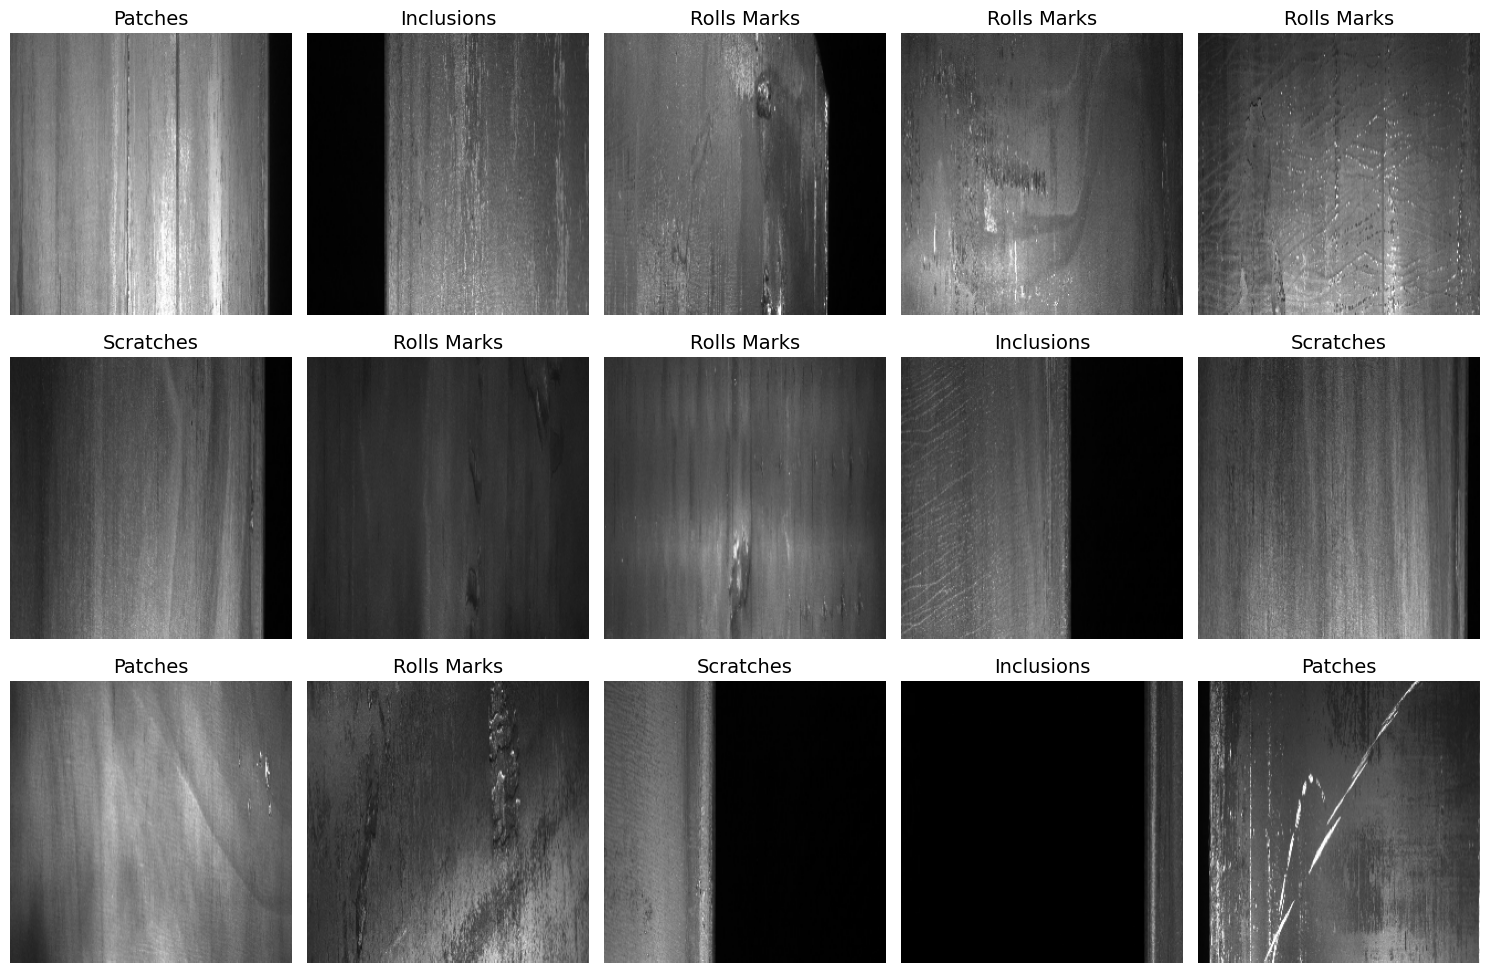

In [7]:
# Visualize sample images from dataset
for images, labels in train_dataset.take(1):
    print(f"Image shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels: {labels [:1].numpy()}")

# Display 15 sample images
plt.figure(figsize=(15, 10))
for images, labels in train_dataset.take(1):
    for i in range(min(15, len(images))):
        ax = plt.subplot(3, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = int(np.argmax(labels[i].numpy()))
        plt.title(class_names[label_idx], fontsize=14)
        plt.axis('off')
plt.tight_layout()
plt.show()

# Data Augmentation


In [8]:
# Preprocessing layers
Resize_Rescale = keras.Sequential([
    keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    keras.layers.Rescaling(1./255)
])

# Data augmentation layers
# These mirror the PyTorch notebook: flip, rotation, translation, zoom, and contrast.
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomTranslation(0.08, 0.08),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomContrast(0.25),
])

In [16]:
AUG_MULTIPLIER = 4
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    image = Resize_Rescale(image)
    return image, label

def preprocess_and_augment(image, label):
    image = Resize_Rescale(image)
    image = data_augmentation(image, training=True)
    return image, label


# Apply augmentation first
train_ds = train_dataset.map(
    preprocess_and_augment,
    num_parallel_calls=AUTOTUNE
)

# Repeat dataset (same as ConcatDataset * multiplier)
train_ds = train_ds.repeat(AUG_MULTIPLIER)

# Shuffle AFTER repeat (important!)
train_ds = train_ds.shuffle(1000)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


val_ds = val_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = test_dataset.map(
    preprocess,
    num_parallel_calls=AUTOTUNE
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(f"Training dataset uses {AUG_MULTIPLIER}x augmentation (PyTorch-style repetition).")

Training dataset uses 4x augmentation (PyTorch-style repetition).


# Assignment: Comparison of the Original and Customized LeNet Models

In this lesson, you have learned about the original LeNet-5 architecture. Your task is to:

1- Train the original LeNet-5 model on the given dataset. Evaluate the model and report its performance (e.g., training loss, validation loss, accuracy, and test accuracy).

2- Modify the original model to create a customized LeNet model by replacing:

**Lazy layers (nn.LazyConv2d, nn.LazyLinear) with standard layers (nn.Conv2d, nn.Linear)

**Average Pooling with Max Pooling

**Sigmoid activations with ReLU

**Xavier initialization with PyTorch’s default  weight initialization

3-Compare the performance of the two models.

In your discussion, answer the following questions:

-How do the two architectures differ (e.g., activation functions, pooling layers, weight initialization, use of lazy layers)?

-Which model achieved better performance?

In [24]:
initializer = keras.initializers.GlorotUniform()

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

x = keras.layers.Conv2D(
    6, kernel_size=5, padding="same",
    activation="sigmoid",
    kernel_initializer=initializer
)(inputs)

x = keras.layers.AveragePooling2D(pool_size=2, strides=2)(x)

x = keras.layers.Conv2D(
    16, kernel_size=5, padding="valid",
    activation="sigmoid",
    kernel_initializer=initializer
)(x)

x = keras.layers.AveragePooling2D(pool_size=2, strides=2)(x)

x = keras.layers.Flatten()(x)

x = keras.layers.Dense(120, activation="sigmoid",
                       kernel_initializer=initializer)(x)

x = keras.layers.Dense(84, activation="sigmoid",
                       kernel_initializer=initializer)(x)

outputs = keras.layers.Dense(len(class_names),
                             kernel_initializer=initializer)(x)

model_original = keras.Model(inputs, outputs)

model_original.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 255, 255, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 127, 127, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 123, 123, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 61, 61, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 59536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 120)            │     7,144,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,157,816 (27.30 MB)

 Trainable params: 7,157,816 (27.30 MB)

 Non-trainable params: 0 (0.00 B)

# Solution for customized LeNet architecture

In [29]:
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

x = keras.layers.Conv2D(6, 5, activation="relu")(inputs)
x = keras.layers.MaxPooling2D(2, 2)(x)

x = keras.layers.Conv2D(16, 5, activation="relu")(x)
x = keras.layers.MaxPooling2D(2, 2)(x)

x = keras.layers.Flatten()(x)

x = keras.layers.Dense(120, activation="relu")(x)
x = keras.layers.Dense(84, activation="relu")(x)
outputs = keras.layers.Dense(len(class_names))(x)

model_lenet = keras.Model(inputs, outputs)

model_lenet.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 251, 251, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 125, 125, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 121, 121, 16)   │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 60, 60, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 120)            │     6,912,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 4)              │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,925,496 (26.42 MB)

 Trainable params: 6,925,496 (26.42 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
EPOCHS = 5

model_lenet.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model_lenet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.4005 - loss: 14.0428 - val_accuracy: 0.5157 - val_loss: 1.3759
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.5995 - loss: 1.0735 - val_accuracy: 0.5630 - val_loss: 1.2182
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.6931 - loss: 0.9065 - val_accuracy: 0.5669 - val_loss: 1.2407
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.7470 - loss: 0.7911 - val_accuracy: 0.5394 - val_loss: 1.2975
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.7943 - loss: 0.6255 - val_accuracy: 0.5551 - val_loss: 1.3021


In [33]:
# Save the model
model_lenet.save("lenet_model.h5")

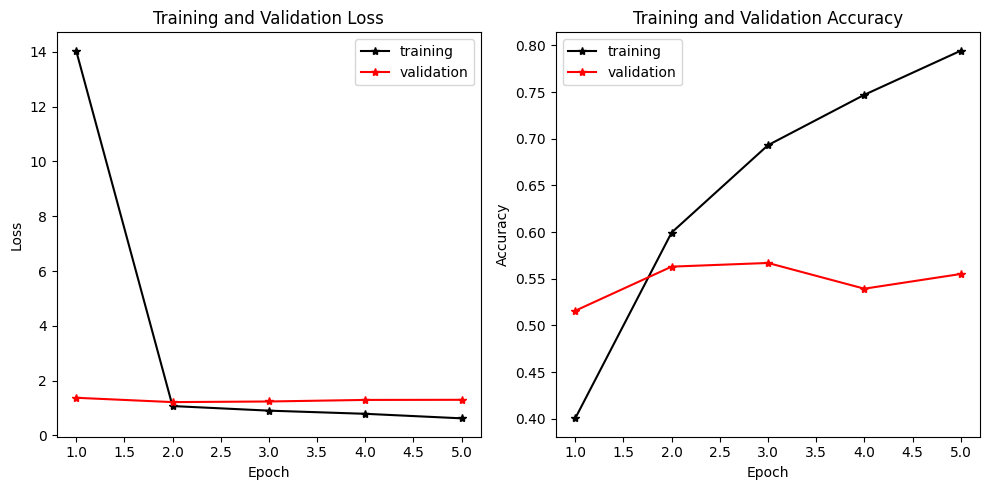

In [34]:
# Plot training history - Loss and Accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, EPOCHS+1), history.history['loss'], color='black', label='training', marker='*')
plt.plot(np.arange(1, EPOCHS+1), history.history['val_loss'], color='red', label='validation', marker='*')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(np.arange(1, EPOCHS+1), history.history['accuracy'], color='black', label='training', marker='*')
plt.plot(np.arange(1, EPOCHS+1), history.history['val_accuracy'], color='red', label='validation', marker='*')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


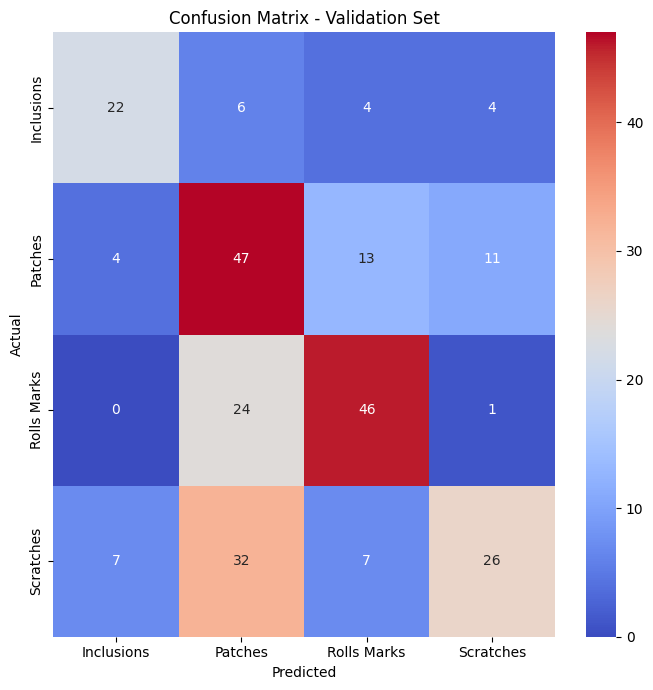


Classification Report:
              precision    recall  f1-score   support

  Inclusions       0.67      0.61      0.64        36
     Patches       0.43      0.63      0.51        75
 Rolls Marks       0.66      0.65      0.65        71
   Scratches       0.62      0.36      0.46        72

    accuracy                           0.56       254
   macro avg       0.59      0.56      0.56       254
weighted avg       0.58      0.56      0.55       254



In [36]:
# Compute confusion matrix and classification report on all validation data
ypred_tot = []
label_tot = []

for images, labels in val_dataset:
    ypred_test = model_lenet.predict(images)
    ypred_test = [np.argmax(i) for i in ypred_test]
    ypred_tot.extend(ypred_test)
    label_tot.extend([np.argmax(label) for label in labels.numpy()])

# Create confusion matrix
cm = tf.math.confusion_matrix(label_tot, ypred_tot, num_classes=len(class_names))

# Display confusion matrix as heatmap
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, cmap="coolwarm", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

# Print classification report with all labels
print("\nClassification Report:")
print(classification_report(label_tot, ypred_tot, labels=range(len(class_names)), target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


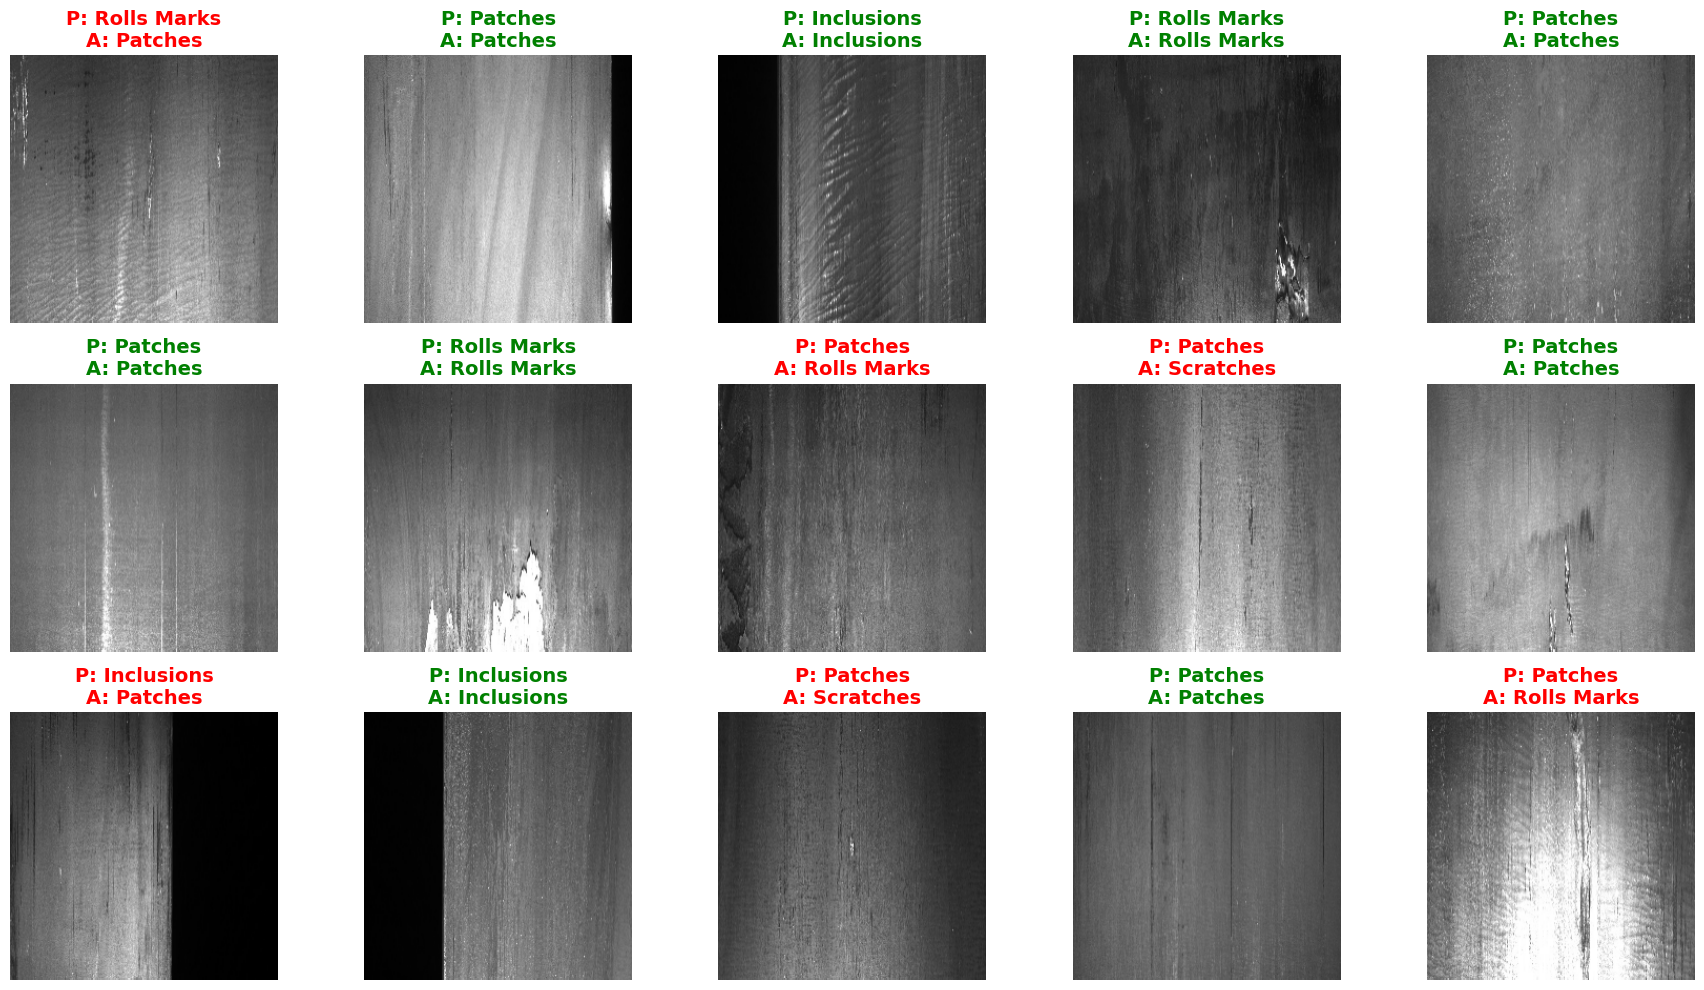


EVALUATING ON TEST SET
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5412 - loss: 1.1950
Test Loss: 1.1950
Test Accuracy: 0.5412 (54.12%)


In [37]:
# Visualize predictions on test set
plt.figure(figsize=(18, 10))
for images, labels in test_dataset.take(1):
    ypred = model_lenet.predict(images)
    ypred = [np.argmax(i) for i in ypred]
    actual_class = [np.argmax(i) for i in labels]
    for i in range(0, 15):
        ax = plt.subplot(3, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        color = 'green' if actual_class[i] == ypred[i] else 'red'
        plt.title(f"P: {class_names[ypred[i]]}\nA: {class_names[actual_class[i]]}", 
                 color=color, fontweight='bold', fontsize=14)

        plt.axis('off')
plt.tight_layout()
plt.show()

# Evaluate model on test set
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)
test_loss, test_accuracy = model_lenet.evaluate(test_dataset, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

# Assignment: Apply the AlexNet model
Your task is apply AlexNet model to the dataset and then repeat the experiment by modifying number of filters (c1- c5), and fully connected layers (fc1, fc2), as well as dropout rates. 
Analyze and explain how these changes affect model performance and discuss how they can be used to customize and improve the model for the specific dataset.


In [40]:
# Build your customized AlexNet-style model
inputs = keras.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    batch_size=BATCH_SIZE
    )
x = Resize_Rescale(inputs)
x = data_augmentation(x)

x = keras.layers.Conv2D(96, kernel_size=(11, 11), strides=4, padding='valid')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)
x = keras.layers.MaxPool2D((3, 3), strides=2)(x)

x = keras.layers.Conv2D(256, kernel_size=(5, 5), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)
x = keras.layers.MaxPool2D((3, 3), strides=2)(x)

x = keras.layers.Conv2D(384, kernel_size=(3, 3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv2D(384, kernel_size=(3, 3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)

x = keras.layers.Conv2D(256, kernel_size=(3, 3), padding='same')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)
x = keras.layers.MaxPool2D((3, 3), strides=2)(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(1024)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)
x = keras.layers.Dropout(0.5)(x)

x = keras.layers.Dense(512)(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.ReLU()(x)
x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(len(class_names), activation='softmax')(x)
model_custom = keras.Model(inputs, outputs, name='CustomAlexNetBN')
model_custom.summary()

Model: "CustomAlexNetBN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (32, 255, 255, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (32, 255, 255, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 255, 255, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (32, 62, 62, 96)       │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (32, 62, 62, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (32, 62, 62, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (32, 30, 30, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (32, 30, 30, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (32, 30, 30, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (32, 30, 30, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (32, 14, 14, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (32, 14, 14, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (32, 14, 14, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (32, 14, 14, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (32, 14, 14, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (32, 14, 14, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (32, 14, 14, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (32, 14, 14, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (32, 14, 14, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (32, 14, 14, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (32, 6, 6, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (32, 9216)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 13,723,908 (52.35 MB)

 Trainable params: 13,718,084 (52.33 MB)

 Non-trainable params: 5,824 (22.75 KB)

In [41]:
EPOCHES = 5
model_custom.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history_custom = model_custom.fit(
    train_dataset,
    batch_size=BATCH_SIZE,
    validation_data=val_dataset,
    verbose=1,
    epochs=EPOCHES
)

Epoch 1/5


c:\Users\marsa964\Desktop\deeplearning\intro-to-dl\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.3769 - loss: 1.5363 - val_accuracy: 0.2835 - val_loss: 54.0710
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.4334 - loss: 1.3098 - val_accuracy: 0.2874 - val_loss: 5.3415
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4789 - loss: 1.2354 - val_accuracy: 0.2717 - val_loss: 7.0846
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.4199 - loss: 1.3895 - val_accuracy: 0.2835 - val_loss: 10.4435
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.4916 - loss: 1.2265 - val_accuracy: 0.3819 - val_loss: 2.5346
